# Ridge Regression — An Illustrated Tour

> When ordinary least squares overfits, **Ridge** adds an L2 penalty to keep coefficients small.

---

**What we cover:**
- Why OLS breaks down with many features
- The Ridge cost function: $J(\theta) + \lambda \|\theta\|_2^2$
- The Ridge trace — how coefficients shrink as $\lambda$ grows
- Bias-variance tradeoff controlled by $\lambda$
- Cross-validation for selecting $\lambda$

## The picture — coefficients shrunk toward zero as $\alpha$ grows
Ridge penalises $\sum\beta_j^2$. Big features still survive but in muted form.

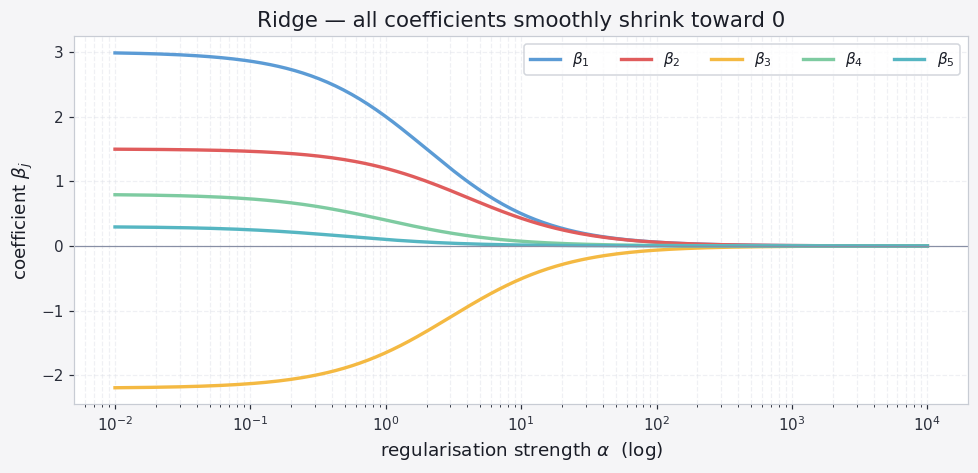

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
alphas = np.logspace(-2, 4, 200)
coefs = np.column_stack([3.0/(1+alphas/2), 1.5/(1+alphas/4), -2.2/(1+alphas/3),
                         0.8/(1+alphas/1), 0.3/(1+alphas/0.5)])
fig, ax = plt.subplots(figsize=(9, 4.4))
for i in range(coefs.shape[1]):
    ax.plot(alphas, coefs[:, i], color=P[i % len(P)], lw=2.2, label=rf'$\beta_{i+1}$')
ax.set_xscale('log'); ax.axhline(0, color='#888fa5', lw=0.8)
ax.set_xlabel(r'regularisation strength $\alpha$  (log)'); ax.set_ylabel(r'coefficient $\beta_j$')
ax.set_title('Ridge — all coefficients smoothly shrink toward 0')
ax.legend(ncol=5); ax.grid(True, which='both'); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error

# ── Presentation style ─────────────────────────────────────────────────────
PLT_STYLE = {
    'figure.facecolor':'#f5f5f7', 'axes.facecolor':'#ffffff',
    'axes.edgecolor':'#c8ccd4',   'axes.labelcolor':'#1a1d27',
    'axes.titlecolor':'#1a1d27',  'xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a',      'grid.color':'#e0e3ea',
    'grid.linestyle': '--',        'grid.alpha': 0.5,
    'text.color':'#1a1d27',       'font.family': 'DejaVu Sans',
    'axes.titlesize': 17,          'axes.labelsize': 13,
    'xtick.labelsize': 11,         'ytick.labelsize': 11,
    'legend.fontsize': 11,         'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4', 'figure.dpi': 120,
}
plt.rcParams.update(PLT_STYLE)

C_DATA  = '#5b9bd5'   # data points
C_OLS   = '#e05c5c'   # OLS / bad fit
C_RIDGE = '#f4b942'   # Ridge / good fit
C_TRUE  = '#7ecba1'   # true function
C_HL    = '#56b6c2'   # highlight
C_GRAD  = '#c678dd'   # gradient / penalty

# ── Dataset: noisy sine curve ───────────────────────────────────────────────
np.random.seed(7)
m       = 20
x_tr    = np.sort(np.random.uniform(0, 1, m))
y_tr    = np.sin(2 * np.pi * x_tr) + np.random.randn(m) * 0.3

x_pl    = np.linspace(0, 1, 300)
y_true  = np.sin(2 * np.pi * x_pl)

DEGREE  = 9

def make_pipeline(alpha):
    """Polynomial degree-9 → StandardScaler → Ridge(alpha) or OLS."""
    model = Ridge(alpha=alpha) if alpha > 0 else LinearRegression()
    return Pipeline([('poly',  PolynomialFeatures(DEGREE, include_bias=True)),
                     ('scale', StandardScaler()),
                     ('model', model)])

print(f'Dataset: {m} training points  |  polynomial degree {DEGREE}')

Dataset: 20 training points  |  polynomial degree 9


---
## The Overfitting Problem

With **degree-9** polynomial features and only 20 training points,
OLS memorises the noise. The fitted curve wiggles wildly between the data points —
great on training data, terrible on new data.

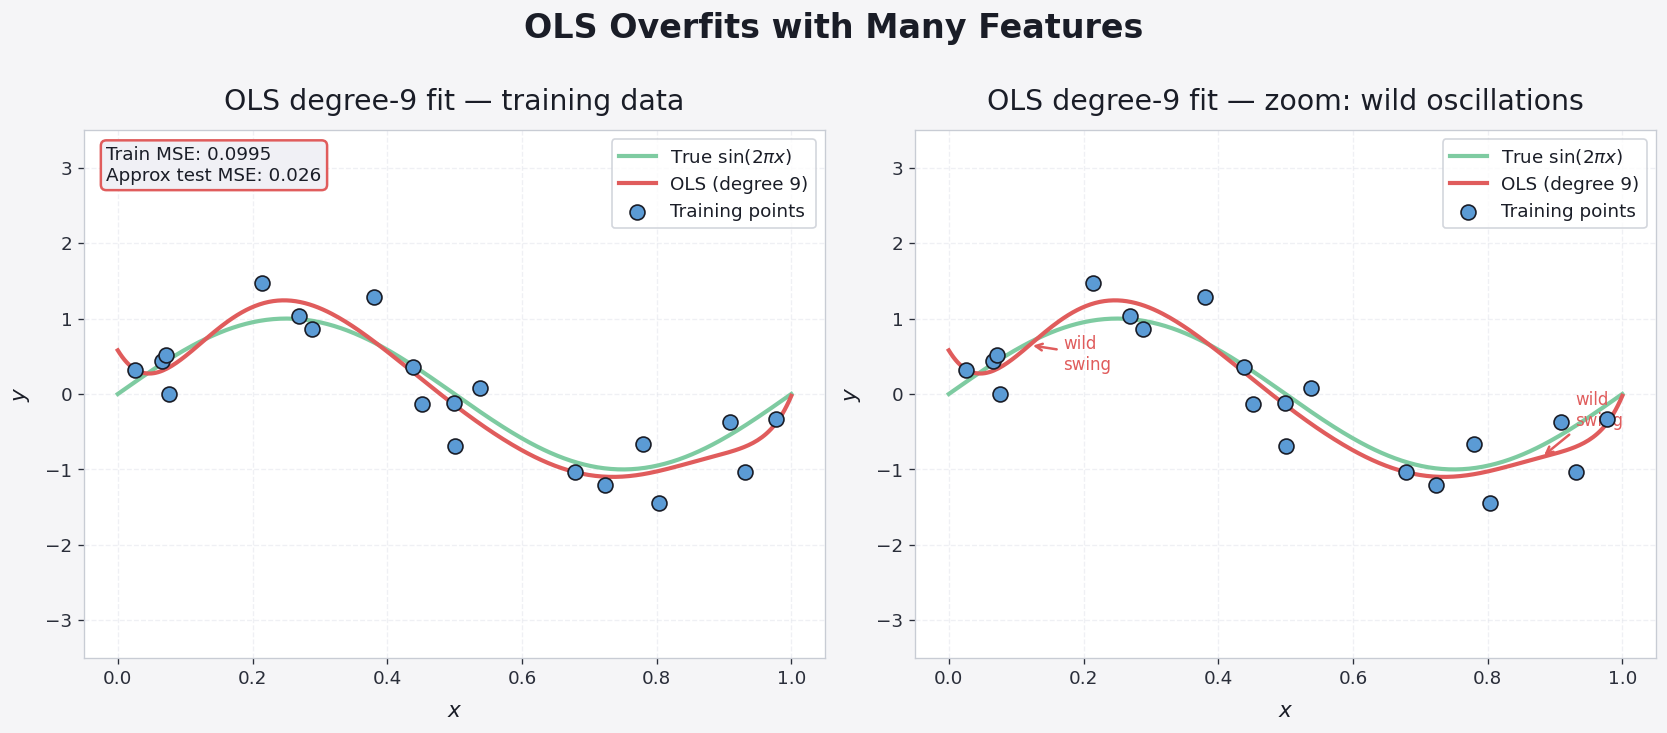

In [3]:
pipe_ols = make_pipeline(alpha=0)
pipe_ols.fit(x_tr.reshape(-1,1), y_tr)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, xlim, title in zip(axes,
    [(-0.05, 1.05), (-0.05, 1.05)],
    ['OLS degree-9 fit — training data',
     'OLS degree-9 fit — zoom: wild oscillations']):

    ax.plot(x_pl, y_true, color=C_TRUE, lw=2.5, label='True $\\sin(2\\pi x)$', zorder=2)
    ax.plot(x_pl, pipe_ols.predict(x_pl.reshape(-1,1)),
            color=C_OLS, lw=2.5, label='OLS (degree 9)', zorder=3)
    ax.scatter(x_tr, y_tr, s=80, c=C_DATA, edgecolors='#1a1d27', lw=1, zorder=4,
               label='Training points')
    ax.set_xlim(*xlim)
    ax.set_ylim(-3.5, 3.5)
    ax.set_xlabel('$x$', labelpad=8); ax.set_ylabel('$y$', labelpad=8)
    ax.set_title(title, pad=12)
    ax.grid(True); ax.legend(loc='upper right')

# Annotate the wild swings
for xi in [0.12, 0.88]:
    yi = pipe_ols.predict([[xi]])[0]
    axes[1].annotate('wild\nswing', xy=(xi, yi), xytext=(xi+0.05, yi*0.5),
                     fontsize=10, color=C_OLS,
                     arrowprops=dict(arrowstyle='->', color=C_OLS, lw=1.5))

train_mse = mean_squared_error(y_tr, pipe_ols.predict(x_tr.reshape(-1,1)))
test_mse  = mean_squared_error(y_true, pipe_ols.predict(x_pl.reshape(-1,1)))
axes[0].text(0.03, 0.97,
    f'Train MSE: {train_mse:.4f}\nApprox test MSE: {test_mse:.3f}',
    transform=axes[0].transAxes, fontsize=11, va='top',
    bbox=dict(boxstyle='round', fc='#f0f0f5', ec=C_OLS, lw=1.5))

fig.suptitle('OLS Overfits with Many Features', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Ridge Adds a Penalty

**Idea:** punish large coefficients. The Ridge cost is:

$$J_\text{Ridge}(\theta) = \underbrace{\frac{1}{2m}\sum_{i=1}^m \bigl(h_\theta(x^{(i)}) - y^{(i)}\bigr)^2}_{\text{fit the data}} + \underbrace{\lambda \sum_{j=1}^n \theta_j^2}_{\text{keep }\theta\text{ small}}$$

- $\lambda = 0$: plain OLS (no regularisation)
- $\lambda \to \infty$: all $\theta_j \to 0$ (underfit)
- Sweet spot in between: **generalises well**

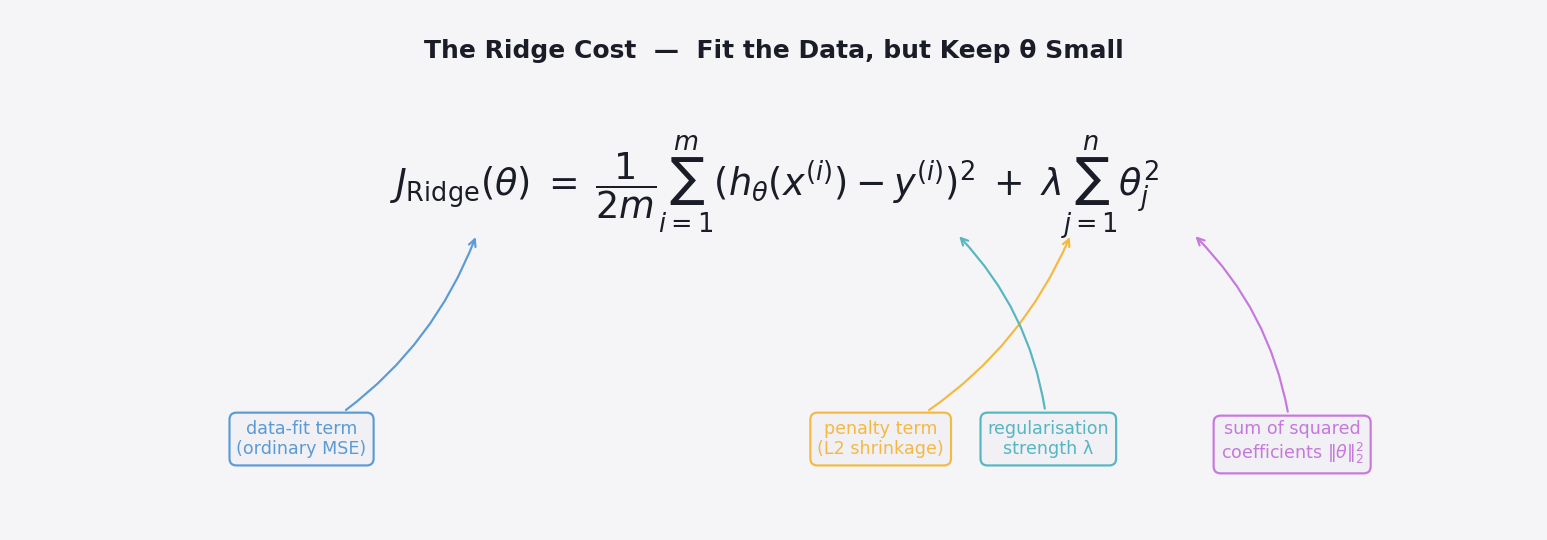

In [4]:
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.set_xlim(0, 10); ax.set_ylim(0, 5); ax.axis('off')

# Big rendered equation
ax.text(5.0, 3.3,
        r'$J_{\mathrm{Ridge}}(\theta) \;=\; \dfrac{1}{2m}\sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)})^{2}'
        r'\;+\;\lambda\sum_{j=1}^{n}\theta_{j}^{2}$',
        fontsize=22, ha='center', va='center', color='#1a1d27')

callouts = [
    (3.05, 3.3, 1.9, 1.05, 'data-fit term\n(ordinary MSE)',           C_DATA),
    (6.95, 3.3, 5.7, 1.05, 'penalty term\n(L2 shrinkage)',            C_RIDGE),
    (6.20, 3.3, 6.8, 1.05, 'regularisation\nstrength λ',              C_HL),
    (7.75, 3.3, 8.4, 1.05, 'sum of squared\ncoefficients $\\|\\theta\\|_2^2$', C_GRAD),
]

for xt, _yt, xb, yb, lbl, col in callouts:
    ax.annotate(lbl,
                xy=(xt, 2.85), xytext=(xb, yb),
                ha='center', va='top', fontsize=10.5, color=col,
                bbox=dict(boxstyle='round,pad=0.4', fc='#f0f0f5',
                          ec=col, lw=1.3),
                arrowprops=dict(arrowstyle='->', color=col, lw=1.3,
                                connectionstyle='arc3,rad=0.18'))

ax.text(5.0, 4.55, 'The Ridge Cost  —  Fit the Data, but Keep θ Small',
        ha='center', fontsize=15, color='#1a1d27', fontweight='bold')

plt.tight_layout()
plt.show()


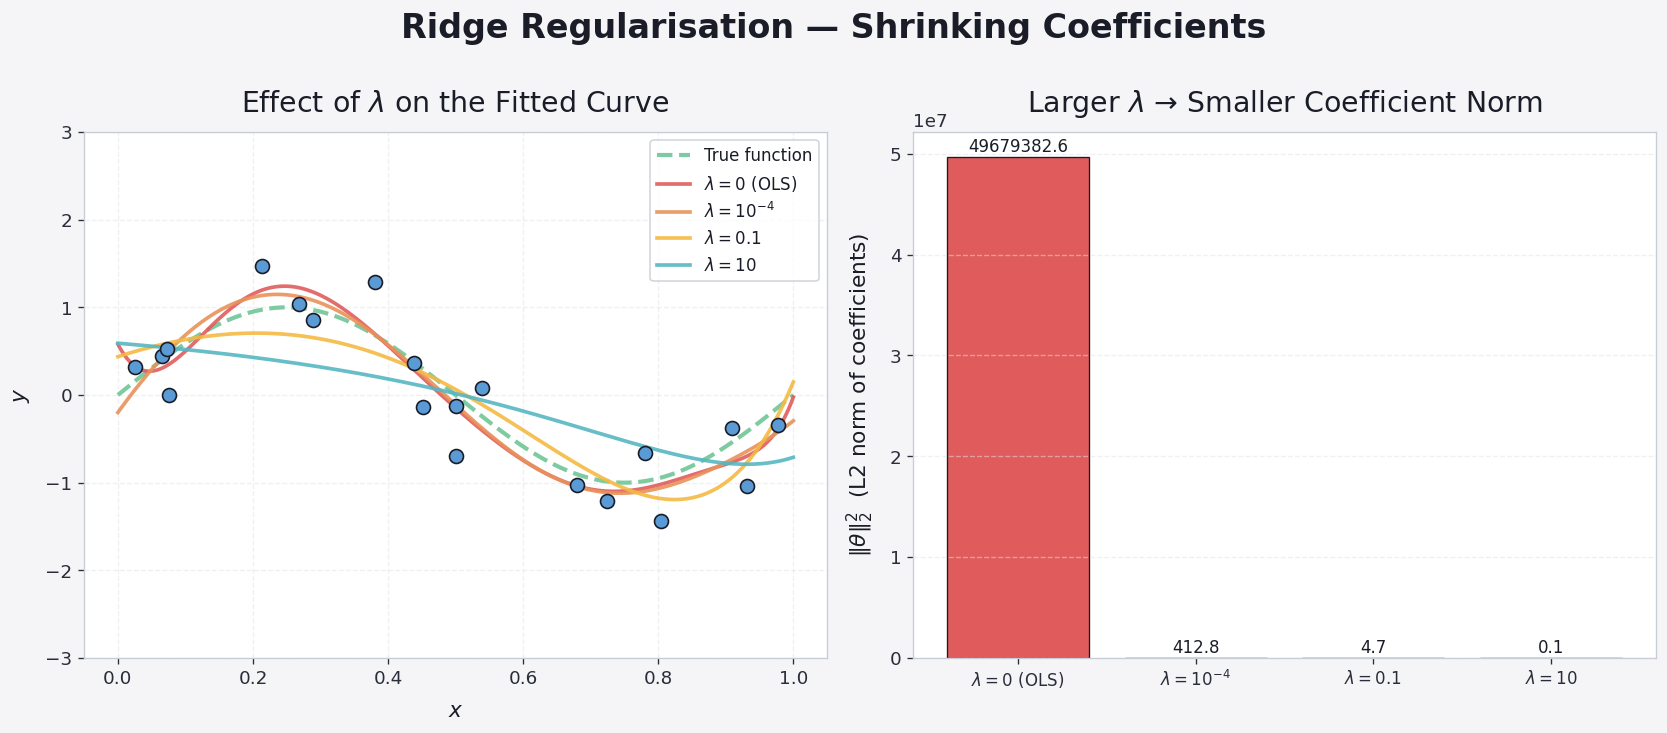

In [5]:
alphas_show = [0, 1e-4, 0.1, 10]
labels_show = ['$\\lambda=0$ (OLS)', '$\\lambda=10^{-4}$', '$\\lambda=0.1$', '$\\lambda=10$']
colors_show = [C_OLS, '#e8925a', C_RIDGE, C_HL]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: fits for different lambda
ax = axes[0]
ax.plot(x_pl, y_true, color=C_TRUE, lw=2.5, ls='--', label='True function', zorder=2)
ax.scatter(x_tr, y_tr, s=70, c=C_DATA, edgecolors='#1a1d27', lw=1, zorder=5)
for alpha, lbl, col in zip(alphas_show, labels_show, colors_show):
    pipe = make_pipeline(alpha)
    pipe.fit(x_tr.reshape(-1,1), y_tr)
    ax.plot(x_pl, pipe.predict(x_pl.reshape(-1,1)),
            color=col, lw=2.2, label=lbl, alpha=0.9)
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-3, 3)
ax.set_xlabel('$x$', labelpad=8); ax.set_ylabel('$y$', labelpad=8)
ax.set_title('Effect of $\\lambda$ on the Fitted Curve', pad=12)
ax.grid(True); ax.legend(loc='upper right', fontsize=10)

# Right: ||theta||^2 (coefficient norm) for each lambda
ax = axes[1]
norms = []
for alpha in alphas_show:
    pipe = make_pipeline(alpha)
    pipe.fit(x_tr.reshape(-1,1), y_tr)
    coef = pipe.named_steps['model'].coef_
    norms.append(np.sum(coef**2))

bars = ax.bar(range(len(alphas_show)), norms, color=colors_show,
              edgecolor='#1a1d27', linewidth=0.8)
ax.set_xticks(range(len(alphas_show)))
ax.set_xticklabels(labels_show, fontsize=10)
ax.set_ylabel('$\\|\\theta\\|_2^2$  (L2 norm of coefficients)', labelpad=8)
ax.set_title('Larger $\\lambda$ → Smaller Coefficient Norm', pad=12)
ax.grid(True, axis='y')
for bar, norm in zip(bars, norms):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(norms)*0.01,
            f'{norm:.1f}', ha='center', fontsize=10, color='#1a1d27')

fig.suptitle('Ridge Regularisation — Shrinking Coefficients', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Visual Sweep — λ Across Eight Orders of Magnitude

The grid below shows six fixed values of $\lambda$ spanning from "essentially OLS" to "heavy shrinkage". Each panel shows the **fitted curve** alongside the held-out test points. Reading left-to-right, top-to-bottom, you can watch the model move from **overfit** (wiggly through training points but missing the truth) through the **sweet spot** to **underfit** (smooth but biased toward zero).

The follow-up shows the **bias–variance curve** with all six sweep values marked, so you can place each visual fit on the train/test MSE landscape.


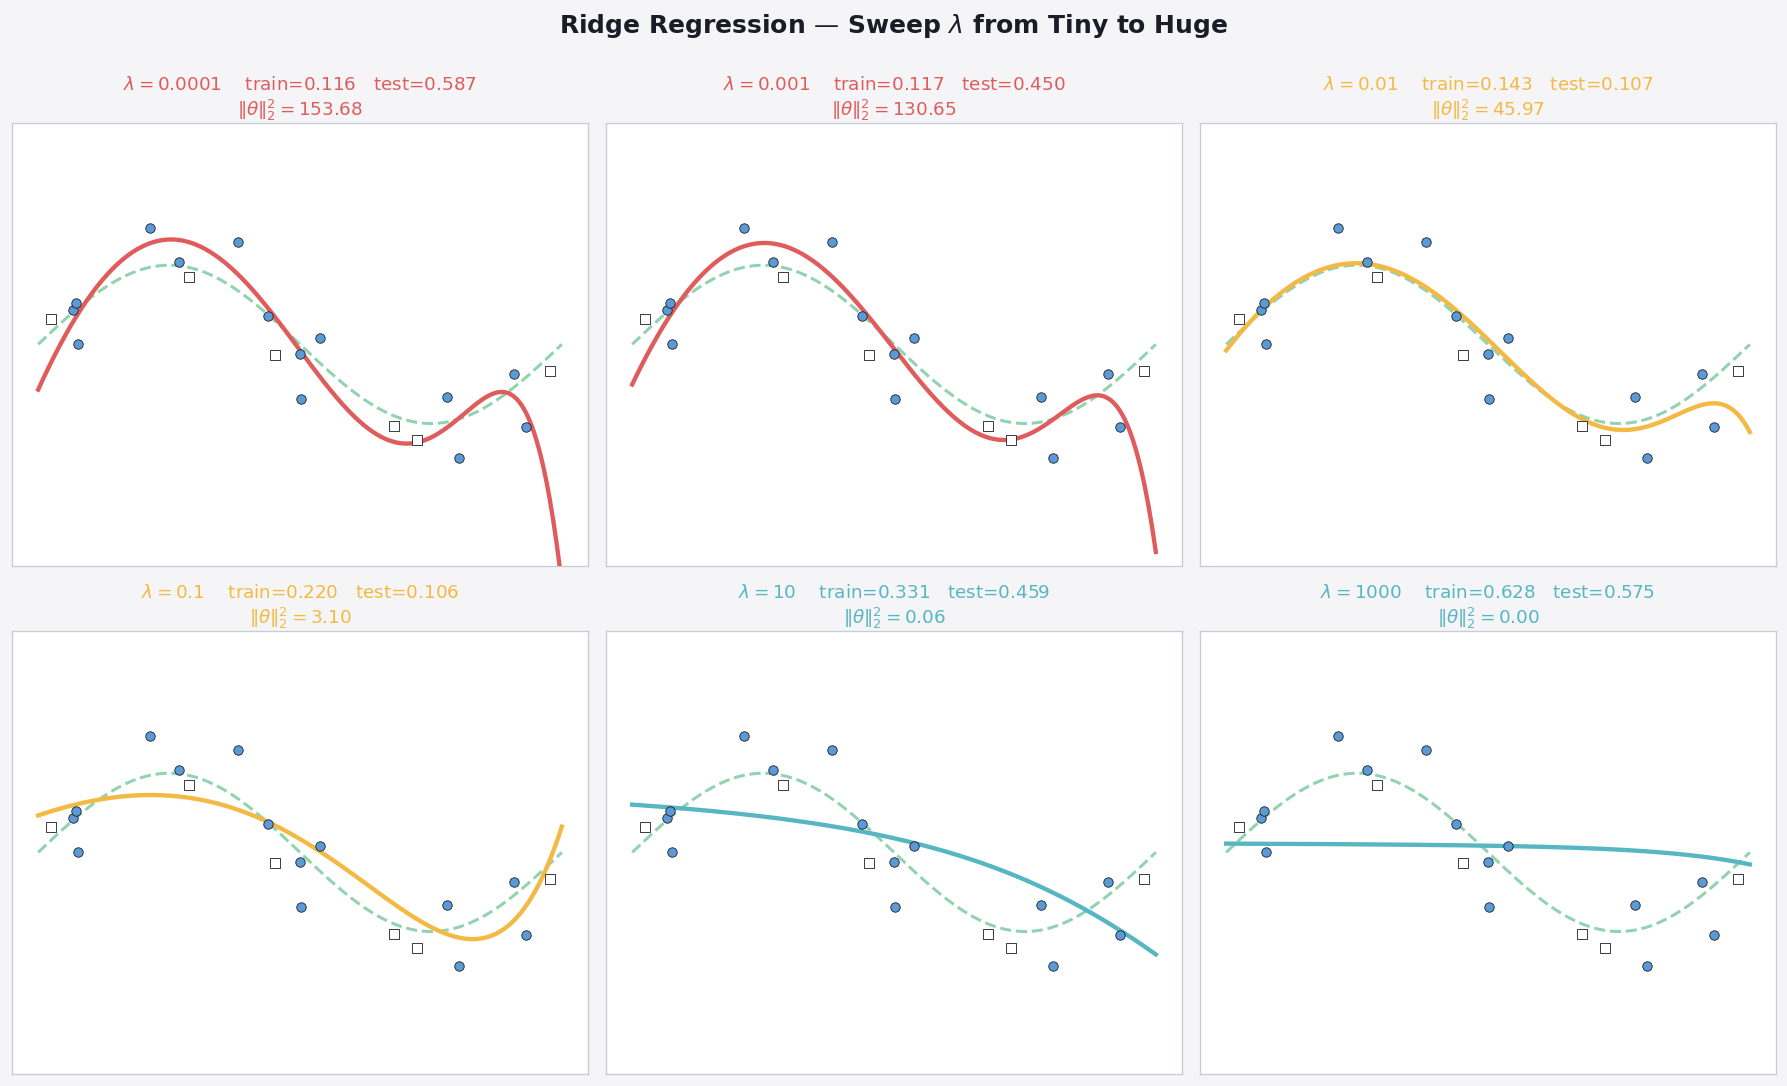

In [6]:
# Hold out 30% for an honest test signal across the sweep
rng_split = np.random.default_rng(1)
perm      = rng_split.permutation(m)
tr_idx    = perm[:int(0.7 * m)]
te_idx    = perm[int(0.7 * m):]
x_tr_in, y_tr_in = x_tr[tr_idx], y_tr[tr_idx]
x_te_in, y_te_in = x_tr[te_idx], y_tr[te_idx]

# Optimal λ on this split (used for the curve below)
_alphas_scan = np.logspace(-4, 3, 80)
_train_curve = []
_test_curve  = []
for _a in _alphas_scan:
    _p = make_pipeline(_a)
    _p.fit(x_tr_in.reshape(-1, 1), y_tr_in)
    _train_curve.append(mean_squared_error(y_tr_in, _p.predict(x_tr_in.reshape(-1, 1))))
    _test_curve.append(mean_squared_error(y_te_in, _p.predict(x_te_in.reshape(-1, 1))))
_alpha_star = _alphas_scan[int(np.argmin(_test_curve))]
_test_min   = float(min(_test_curve))

# Six representative λ values spanning eight orders of magnitude
_lam_panel = [1e-4, 1e-3, 1e-2, 1e-1, 1e1, 1e3]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, lam in zip(axes.ravel(), _lam_panel):
    pipe = make_pipeline(lam if lam > 1e-10 else 0)
    pipe.fit(x_tr_in.reshape(-1, 1), y_tr_in)

    train_e = mean_squared_error(y_tr_in, pipe.predict(x_tr_in.reshape(-1, 1)))
    test_e  = mean_squared_error(y_te_in, pipe.predict(x_te_in.reshape(-1, 1)))
    coef    = pipe.named_steps['model'].coef_
    norm2   = float(np.sum(coef ** 2))

    if   lam < _alpha_star * 0.1:  regime_col = C_OLS
    elif lam > _alpha_star * 10:   regime_col = C_HL
    else:                          regime_col = C_RIDGE

    ax.plot(x_pl, y_true, color=C_TRUE, lw=1.8, ls='--', alpha=0.85, zorder=2)
    ax.plot(x_pl, pipe.predict(x_pl.reshape(-1, 1)),
            color=regime_col, lw=2.6, zorder=4)
    ax.scatter(x_tr_in, y_tr_in, s=32, c=C_DATA,
               edgecolors='#1a1d27', lw=0.5, zorder=5)
    ax.scatter(x_te_in, y_te_in, s=32, c='#ffffff',
               edgecolors='#1a1d27', lw=0.5, marker='s', zorder=5)
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-2.8, 2.8)
    ax.set_title(f'$\\lambda = {lam:g}$    train={train_e:.3f}   test={test_e:.3f}\n'
                 f'$\\|\\theta\\|_2^2 = {norm2:.2f}$',
                 color=regime_col, fontsize=11, pad=4)
    ax.set_xticks([]); ax.set_yticks([])
    ax.grid(True, alpha=0.3)

fig.suptitle('Ridge Regression — Sweep $\\lambda$ from Tiny to Huge',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout(); plt.show()


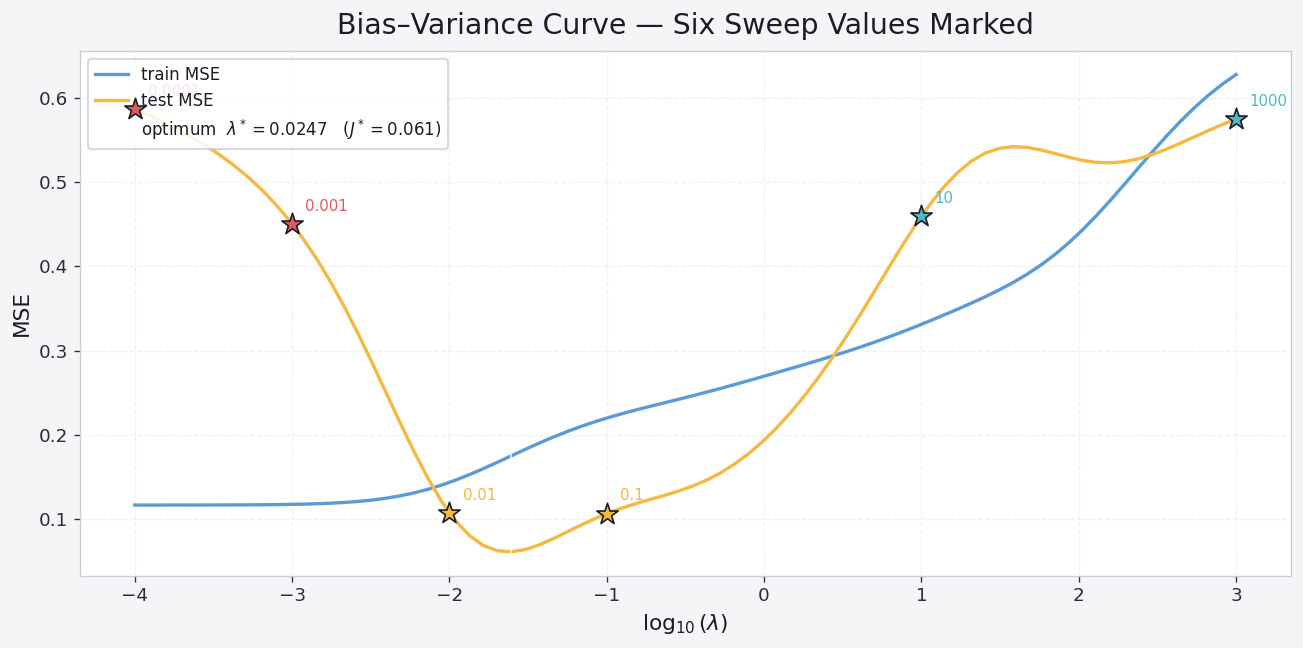

In [7]:
# Bias-variance curve with the six sweep values marked
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(np.log10(_alphas_scan), _train_curve, color=C_DATA, lw=2, label='train MSE')
ax.plot(np.log10(_alphas_scan), _test_curve,  color=C_RIDGE, lw=2, label='test MSE')
ax.axvline(np.log10(_alpha_star), color='white', ls='--', lw=1.2, alpha=0.7,
           label=f'optimum  $\\lambda^*={_alpha_star:.3g}$   ($J^*={_test_min:.3f}$)')

for lam in _lam_panel:
    pipe = make_pipeline(lam if lam > 1e-10 else 0)
    pipe.fit(x_tr_in.reshape(-1, 1), y_tr_in)
    te = mean_squared_error(y_te_in, pipe.predict(x_te_in.reshape(-1, 1)))
    if   lam < _alpha_star * 0.1:  col = C_OLS
    elif lam > _alpha_star * 10:   col = C_HL
    else:                          col = C_RIDGE
    ax.scatter([np.log10(lam)], [te], s=180, c=col, marker='*',
               edgecolors='#1a1d27', lw=1, zorder=8)
    ax.annotate(f'{lam:g}', (np.log10(lam), te),
                textcoords='offset points', xytext=(8, 8),
                fontsize=9, color=col)

ax.set_xlabel('$\\log_{10}(\\lambda)$'); ax.set_ylabel('MSE')
ax.set_title('Bias–Variance Curve — Six Sweep Values Marked', pad=10)
ax.legend(loc='upper left', fontsize=10, framealpha=0.85)
ax.grid(True)
plt.tight_layout(); plt.show()


---
## The Ridge Trace

As $\lambda$ increases from 0 to $\infty$, every coefficient is **continuously shrunk toward zero**.
The path each coefficient follows is called the **Ridge trace**.

- All coefficients start at their OLS values ($\lambda=0$)
- All converge to 0 as $\lambda \to \infty$
- The traces are smooth — no coefficient ever reaches exactly 0
  *(this distinguishes Ridge from Lasso)*

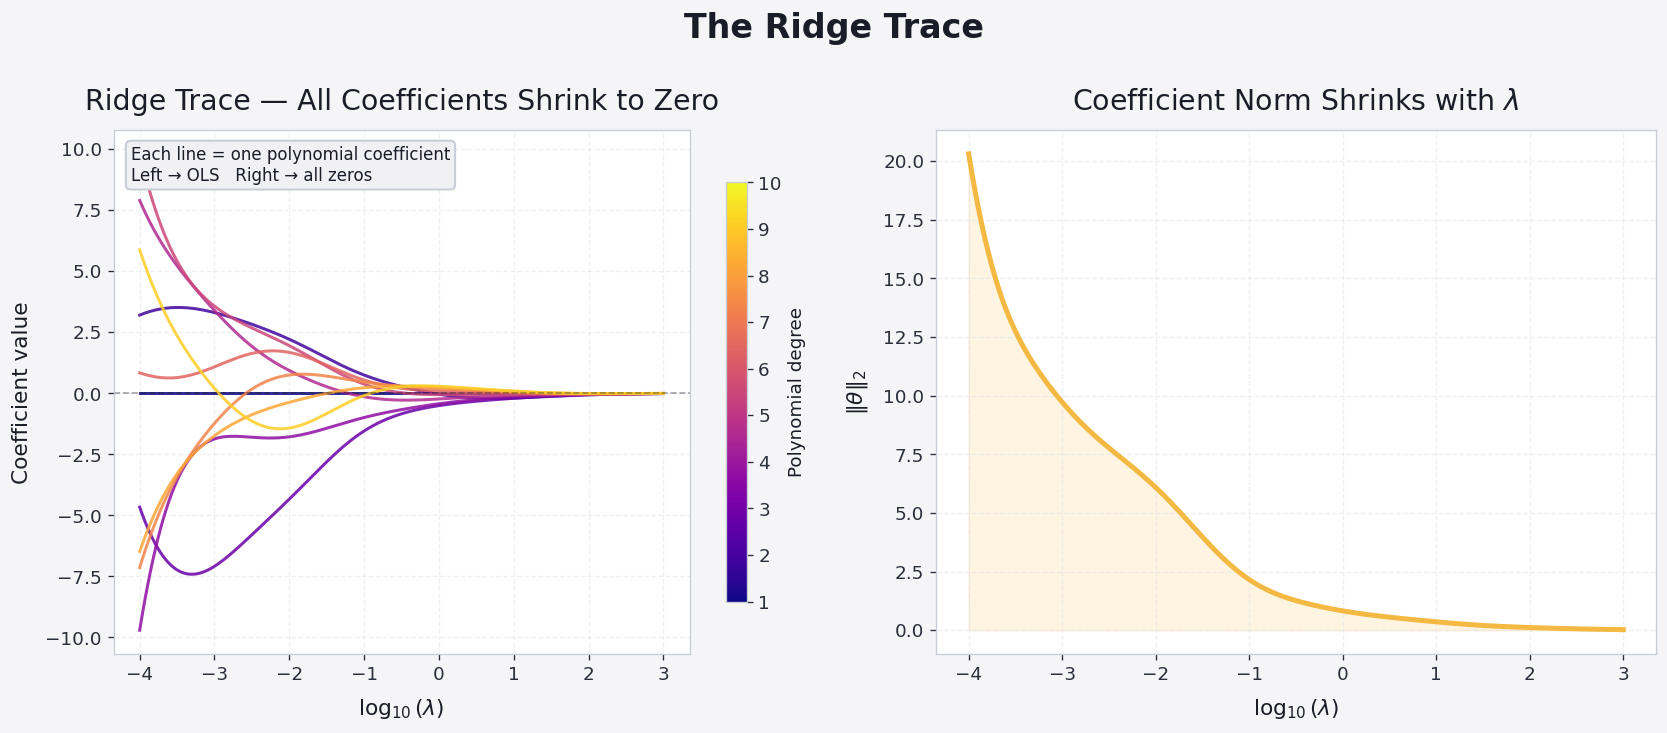

In [8]:
alphas = np.logspace(-4, 3, 200)

# Collect coefficients for each alpha
coef_paths = []
for alpha in alphas:
    pipe = make_pipeline(alpha)
    pipe.fit(x_tr.reshape(-1,1), y_tr)
    coef_paths.append(pipe.named_steps['model'].coef_)
coef_paths = np.array(coef_paths)   # (n_alphas, n_features)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: coefficient paths
ax = axes[0]
cmap = plt.cm.plasma
for j in range(coef_paths.shape[1]):
    col = cmap(j / coef_paths.shape[1])
    ax.plot(np.log10(alphas), coef_paths[:, j], color=col, lw=1.8, alpha=0.85)

ax.axhline(0, color='#1a1d27', ls='--', lw=1, alpha=0.4)
ax.set_xlabel('$\\log_{10}(\\lambda)$', labelpad=8)
ax.set_ylabel('Coefficient value', labelpad=8)
ax.set_title('Ridge Trace — All Coefficients Shrink to Zero', pad=12)
ax.grid(True)
ax.text(0.03, 0.97, 'Each line = one polynomial coefficient\nLeft → OLS   Right → all zeros',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', fc='#f0f0f5', ec='#c8ccd4', lw=1.2))

# Colourbar for degree index
sm = plt.cm.ScalarMappable(cmap='plasma',
    norm=plt.Normalize(vmin=1, vmax=coef_paths.shape[1]))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.8)
cbar.set_label('Polynomial degree', fontsize=11)
cbar.ax.tick_params(labelcolor='#2a2e3a')

# Right: L2 norm of theta vs lambda
ax = axes[1]
norm_path = np.sqrt(np.sum(coef_paths**2, axis=1))
ax.plot(np.log10(alphas), norm_path, color=C_RIDGE, lw=3)
ax.fill_between(np.log10(alphas), 0, norm_path, color=C_RIDGE, alpha=0.15)
ax.set_xlabel('$\\log_{10}(\\lambda)$', labelpad=8)
ax.set_ylabel('$\\|\\theta\\|_2$', labelpad=8)
ax.set_title('Coefficient Norm Shrinks with $\\lambda$', pad=12)
ax.grid(True)

fig.suptitle('The Ridge Trace', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## 🔵 Geometric Intuition — Ridge as Constrained Optimisation

Adding $\lambda\|\theta\|_2^2$ to the cost is mathematically equivalent to
**constraining** $\|\theta\|_2 \le t$ for some radius $t$ that depends on $\lambda$.
The picture in coefficient space is:

> *Drop a ball of radius $t$ centred at the origin. The Ridge solution is the
> point where the smallest OLS cost ellipse just **touches** that ball.*

Because the ball is **round**, the tangent point is generally an interior
point — every coefficient is non-zero but pulled toward the origin. (The Lasso
notebook will show what changes when the ball becomes a diamond.)

The plot below uses two correlated features so the OLS cost surface is a long
ellipse — exactly the situation where regularisation matters most.



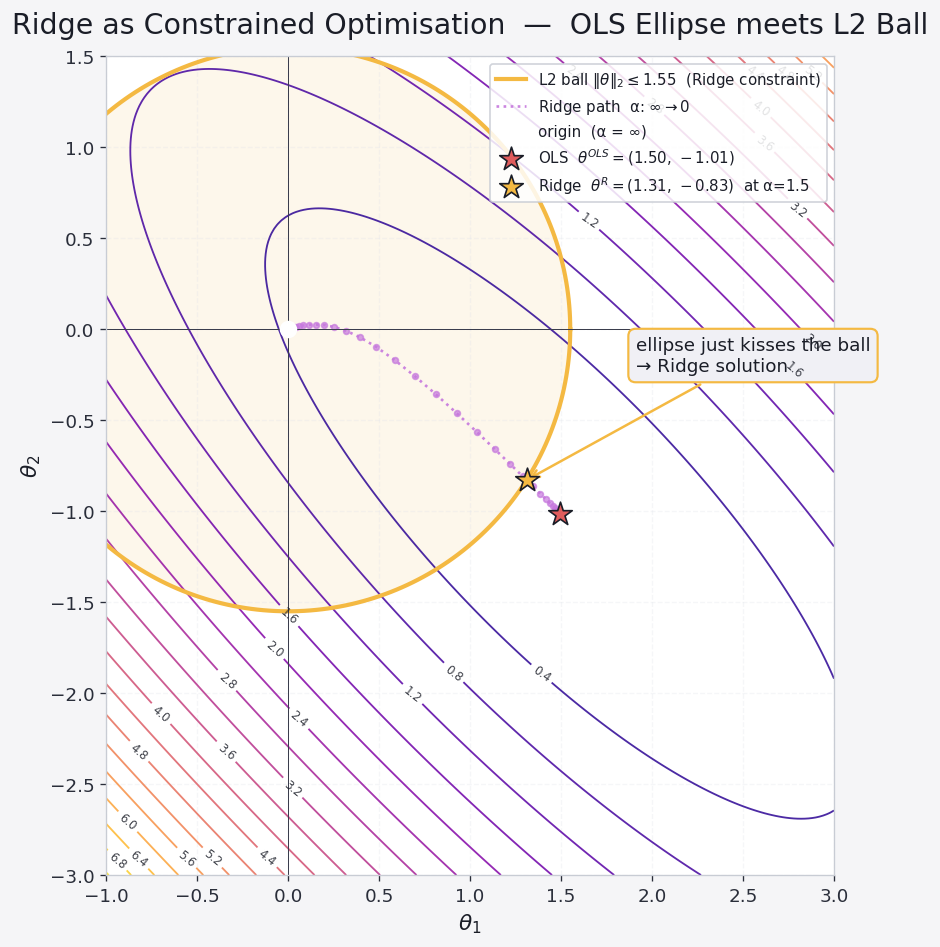

In [9]:
# Two correlated features → an elongated OLS cost ellipse in 2-D θ space
rng_g  = np.random.default_rng(0)
m_g    = 60
x1     = rng_g.normal(0, 1, m_g)
x2     = 0.85 * x1 + rng_g.normal(0, 0.5, m_g)         # correlated with x1
X_g    = np.column_stack([x1, x2])
true_t = np.array([1.5, -1.0])
y_g    = X_g @ true_t + rng_g.normal(0, 0.3, m_g)

# OLS minimiser and a grid for cost contours
theta_ols = np.linalg.lstsq(X_g, y_g, rcond=None)[0]

def _Jdata(t1g, t2g):
    err = X_g @ np.array([t1g, t2g]) - y_g
    return np.sum(err ** 2) / (2 * m_g)

th1g = np.linspace(-1.0, 3.0, 200)
th2g = np.linspace(-3.0, 1.5, 200)
TH1, TH2 = np.meshgrid(th1g, th2g)
J_data   = np.vectorize(_Jdata)(TH1, TH2)

# Ridge solutions along an α path
alphas_g = np.logspace(-3, 3, 40)
ridge_path = []
for a in alphas_g:
    th = np.linalg.solve(X_g.T @ X_g + a * np.eye(2), X_g.T @ y_g)
    ridge_path.append(th)
ridge_path = np.array(ridge_path)

# Pick one α to highlight as "the constraint that yields this θ*"
a_show     = 1.5
theta_show = np.linalg.solve(X_g.T @ X_g + a_show * np.eye(2), X_g.T @ y_g)
r_show     = np.linalg.norm(theta_show)
phi        = np.linspace(0, 2 * np.pi, 300)
ball_x     = r_show * np.cos(phi)
ball_y     = r_show * np.sin(phi)

fig, ax = plt.subplots(figsize=(9, 8))

# Cost contours
cs = ax.contour(TH1, TH2, J_data, levels=18, cmap='plasma', linewidths=1.1, alpha=0.85)
ax.clabel(cs, inline=True, fontsize=7, fmt='%.1f', colors='#1a1d27')

# L2 ball — Ridge's feasible region
ax.plot(ball_x, ball_y, color=C_RIDGE, lw=2.5,
        label=f'L2 ball $\\|\\theta\\|_2 \\leq {r_show:.2f}$  (Ridge constraint)')
ax.fill(ball_x, ball_y, color=C_RIDGE, alpha=0.10)

# Regularisation path
ax.plot(ridge_path[:, 0], ridge_path[:, 1], color=C_GRAD, lw=1.6, ls=':', alpha=0.9,
        label='Ridge path  α: $\\infty \\to 0$')
ax.scatter(ridge_path[:, 0], ridge_path[:, 1], s=12, c=C_GRAD, alpha=0.7)

# Key points
ax.scatter([0], [0], s=90, c='#ffffff', zorder=8, label='origin  (α = ∞)')
ax.scatter([theta_ols[0]], [theta_ols[1]], s=220, c=C_OLS, marker='*',
           edgecolors='#1a1d27', lw=1, zorder=10,
           label=f'OLS  $\\theta^{{OLS}}=({theta_ols[0]:.2f},\\,{theta_ols[1]:.2f})$')
ax.scatter([theta_show[0]], [theta_show[1]], s=220, c=C_RIDGE, marker='*',
           edgecolors='#1a1d27', lw=1, zorder=10,
           label=f'Ridge  $\\theta^{{R}}=({theta_show[0]:.2f},\\,{theta_show[1]:.2f})$  at α={a_show:g}')

# The "ellipse touches the ball" — annotate the tangent
ax.annotate('ellipse just kisses the ball\n→ Ridge solution',
            xy=(theta_show[0], theta_show[1]),
            xytext=(theta_show[0] + 0.6, theta_show[1] + 0.6),
            fontsize=11, color='#1a1d27',
            bbox=dict(boxstyle='round,pad=0.4', fc='#f0f0f5', ec=C_RIDGE, lw=1.3),
            arrowprops=dict(arrowstyle='->', color=C_RIDGE, lw=1.5))

ax.axhline(0, color='#3a3d4d', lw=0.6); ax.axvline(0, color='#3a3d4d', lw=0.6)
ax.set_xlabel('$\\theta_1$'); ax.set_ylabel('$\\theta_2$')
ax.set_title('Ridge as Constrained Optimisation  —  OLS Ellipse meets L2 Ball', pad=14)
ax.legend(loc='upper right', fontsize=9, framealpha=0.85)
ax.set_xlim(th1g.min(), th1g.max())
ax.set_ylim(th2g.min(), th2g.max())
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## Bias-Variance Tradeoff

$\lambda$ controls the bias-variance tradeoff:

| $\lambda$ | Bias | Variance | Result |
|---|---|---|---|
| Too small | Low | **High** | Overfits — high test error |
| Just right | Medium | Medium | Best generalisation |
| Too large | **High** | Low | Underfits — high train and test error |

The **test error** forms a U-shaped curve. The optimal $\lambda$ sits at the minimum.

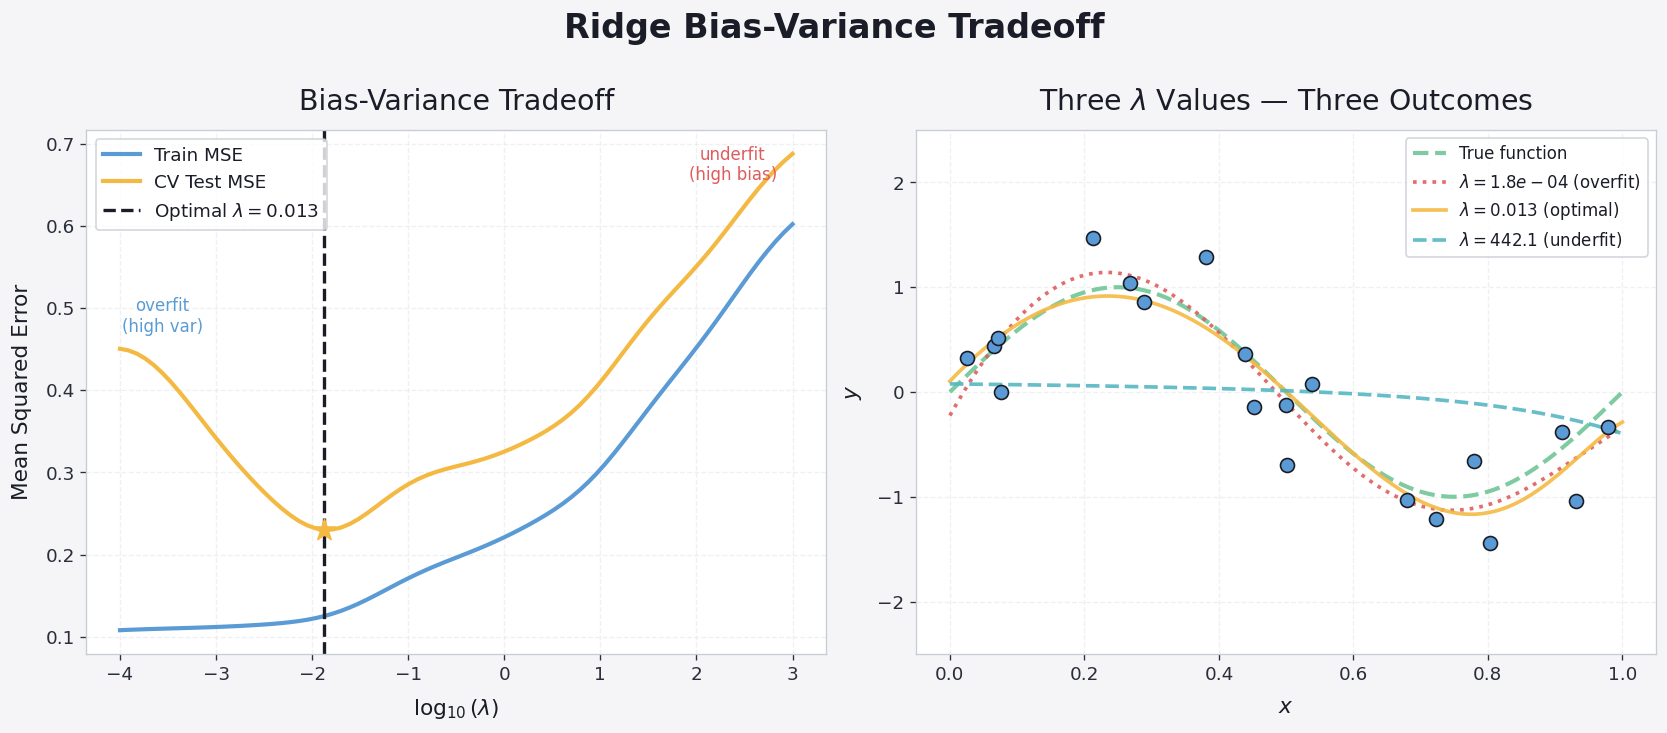

In [10]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
alphas_cv = np.logspace(-4, 3, 80)

train_mse_list, test_mse_list = [], []
for alpha in alphas_cv:
    pipe = make_pipeline(alpha)
    # train MSE
    pipe.fit(x_tr.reshape(-1,1), y_tr)
    train_mse_list.append(mean_squared_error(y_tr, pipe.predict(x_tr.reshape(-1,1))))
    # CV test MSE
    cv_scores = cross_val_score(make_pipeline(alpha),
                                x_tr.reshape(-1,1), y_tr,
                                cv=kf, scoring='neg_mean_squared_error')
    test_mse_list.append(-cv_scores.mean())

train_mse_arr = np.array(train_mse_list)
test_mse_arr  = np.array(test_mse_list)
best_idx      = np.argmin(test_mse_arr)
best_alpha    = alphas_cv[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: train & test MSE vs log(lambda)
ax = axes[0]
ax.plot(np.log10(alphas_cv), train_mse_arr, color=C_DATA, lw=2.5, label='Train MSE')
ax.plot(np.log10(alphas_cv), test_mse_arr,  color=C_RIDGE, lw=2.5, label='CV Test MSE')
ax.axvline(np.log10(best_alpha), color='#1a1d27', ls='--', lw=2,
           label=f'Optimal $\\lambda={best_alpha:.3f}$')
ax.scatter([np.log10(best_alpha)], [test_mse_arr[best_idx]],
           s=180, c=C_RIDGE, zorder=6, marker='*')
ax.set_xlabel('$\\log_{10}(\\lambda)$', labelpad=8)
ax.set_ylabel('Mean Squared Error', labelpad=8)
ax.set_title('Bias-Variance Tradeoff', pad=12)
ax.grid(True); ax.legend(loc='upper left')

# Annotate regions
ax.text(np.log10(alphas_cv[5]),  test_mse_arr[5]  + 0.05, 'overfit\n(high var)',
        ha='center', fontsize=10, color=C_DATA)
ax.text(np.log10(alphas_cv[-8]), test_mse_arr[-8] + 0.05, 'underfit\n(high bias)',
        ha='center', fontsize=10, color=C_OLS)

# Right: fits at 3 lambda values (bad small, optimal, bad large)
ax = axes[1]
ax.plot(x_pl, y_true, color=C_TRUE, lw=2.5, ls='--', label='True function', zorder=2)
ax.scatter(x_tr, y_tr, s=70, c=C_DATA, edgecolors='#1a1d27', lw=1, zorder=5)
for alpha_show, lbl, col, ls in [
    (alphas_cv[3],   f'$\\lambda={alphas_cv[3]:.1e}$ (overfit)',  C_OLS,   ':'),
    (best_alpha,     f'$\\lambda={best_alpha:.3f}$ (optimal)',    C_RIDGE, '-'),
    (alphas_cv[-5],  f'$\\lambda={alphas_cv[-5]:.1f}$ (underfit)', C_HL,   '--'),
]:
    pipe = make_pipeline(alpha_show)
    pipe.fit(x_tr.reshape(-1,1), y_tr)
    ax.plot(x_pl, pipe.predict(x_pl.reshape(-1,1)),
            color=col, lw=2.2, label=lbl, ls=ls, alpha=0.9)
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-2.5, 2.5)
ax.set_xlabel('$x$', labelpad=8); ax.set_ylabel('$y$', labelpad=8)
ax.set_title('Three $\\lambda$ Values — Three Outcomes', pad=12)
ax.grid(True); ax.legend(loc='upper right', fontsize=10)

fig.suptitle('Ridge Bias-Variance Tradeoff', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Cross-Validation for $\lambda$

We can't use training error to pick $\lambda$ — it always decreases as $\lambda \to 0$.
Instead we use **cross-validation**: hold out a fraction of the training data,
try many $\lambda$ values, and pick the one with the lowest held-out error.

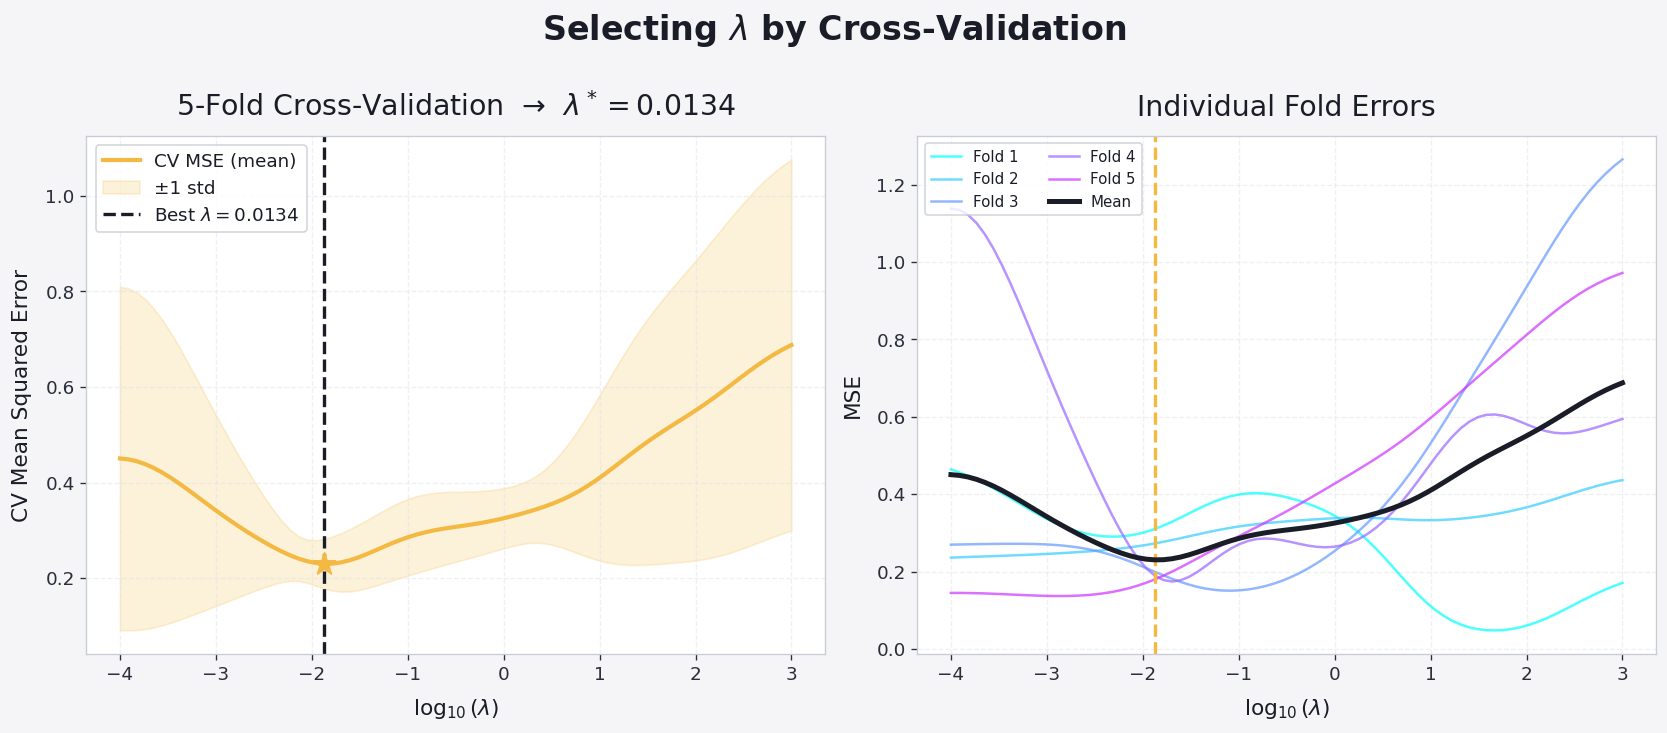

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: CV error with std band
fold_scores = np.array([
    cross_val_score(make_pipeline(a), x_tr.reshape(-1,1), y_tr,
                    cv=kf, scoring='neg_mean_squared_error')
    for a in alphas_cv
])
cv_mean = -fold_scores.mean(axis=1)
cv_std  =  fold_scores.std(axis=1)

ax = axes[0]
ax.plot(np.log10(alphas_cv), cv_mean, color=C_RIDGE, lw=2.5, label='CV MSE (mean)')
ax.fill_between(np.log10(alphas_cv),
                cv_mean - cv_std, cv_mean + cv_std,
                color=C_RIDGE, alpha=0.20, label='±1 std')
ax.axvline(np.log10(best_alpha), color='#1a1d27', ls='--', lw=2,
           label=f'Best $\\lambda = {best_alpha:.4f}$')
ax.scatter([np.log10(best_alpha)], [cv_mean[best_idx]],
           s=200, c=C_RIDGE, marker='*', zorder=7)
ax.set_xlabel('$\\log_{10}(\\lambda)$', labelpad=8)
ax.set_ylabel('CV Mean Squared Error', labelpad=8)
ax.set_title(f'5-Fold Cross-Validation  →  $\\lambda^* = {best_alpha:.4f}$', pad=12)
ax.grid(True); ax.legend(loc='upper left')

# Right: individual fold curves
ax = axes[1]
cmap2 = plt.cm.cool
for fold_idx in range(fold_scores.shape[1]):
    col = cmap2(fold_idx / fold_scores.shape[1])
    ax.plot(np.log10(alphas_cv), -fold_scores[:, fold_idx],
            color=col, lw=1.5, alpha=0.7,
            label=f'Fold {fold_idx+1}')
ax.plot(np.log10(alphas_cv), cv_mean, color='#1a1d27', lw=3, label='Mean', zorder=5)
ax.axvline(np.log10(best_alpha), color=C_RIDGE, ls='--', lw=2)
ax.set_xlabel('$\\log_{10}(\\lambda)$', labelpad=8)
ax.set_ylabel('MSE', labelpad=8)
ax.set_title('Individual Fold Errors', pad=12)
ax.grid(True); ax.legend(loc='upper left', fontsize=9, ncol=2)

fig.suptitle('Selecting $\\lambda$ by Cross-Validation', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Ridge vs OLS — Final Comparison

With the optimal $\lambda$ found by cross-validation,
Ridge recovers the smooth underlying sine curve while OLS memorises the noise.

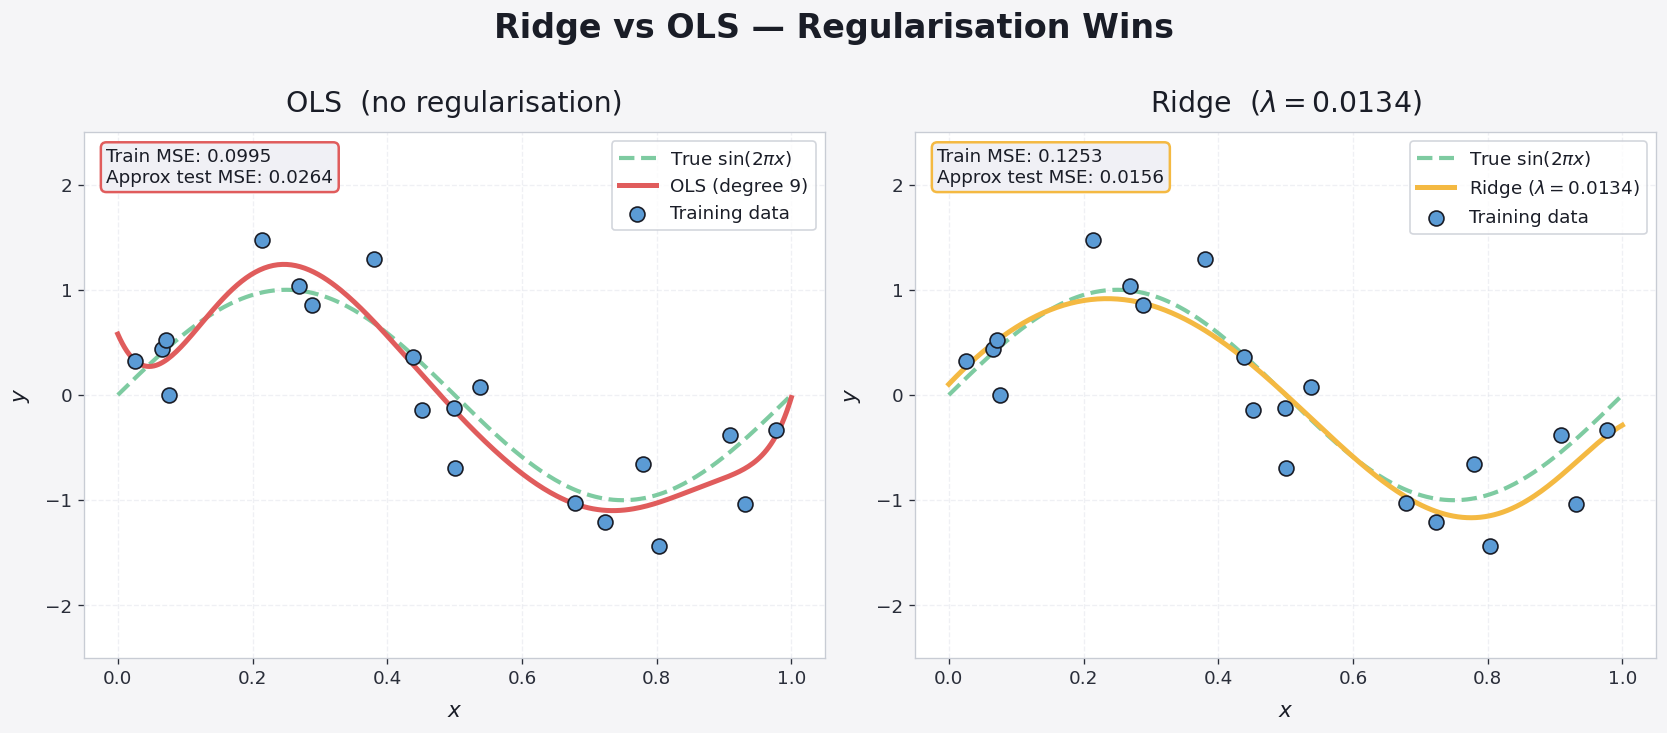

In [12]:
pipe_ridge = make_pipeline(best_alpha)
pipe_ridge.fit(x_tr.reshape(-1,1), y_tr)

pipe_ols2  = make_pipeline(0)
pipe_ols2.fit(x_tr.reshape(-1,1), y_tr)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, pipe, col, title, lbl in [
    (axes[0], pipe_ols2, C_OLS,   'OLS  (no regularisation)',        'OLS (degree 9)'),
    (axes[1], pipe_ridge, C_RIDGE, f'Ridge  ($\\lambda={best_alpha:.4f}$)', f'Ridge ($\\lambda={best_alpha:.4f}$)'),
]:
    ax.plot(x_pl, y_true, color=C_TRUE, lw=2.5, ls='--', label='True $\\sin(2\\pi x)$', zorder=2)
    ax.plot(x_pl, pipe.predict(x_pl.reshape(-1,1)), color=col, lw=3, label=lbl, zorder=3)
    ax.scatter(x_tr, y_tr, s=80, c=C_DATA, edgecolors='#1a1d27', lw=1, zorder=4,
               label='Training data')
    train_e = mean_squared_error(y_tr, pipe.predict(x_tr.reshape(-1,1)))
    test_e  = mean_squared_error(y_true, pipe.predict(x_pl.reshape(-1,1)))
    ax.text(0.03, 0.97, f'Train MSE: {train_e:.4f}\nApprox test MSE: {test_e:.4f}',
            transform=ax.transAxes, fontsize=11, va='top',
            bbox=dict(boxstyle='round', fc='#f0f0f5', ec=col, lw=1.5))
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-2.5, 2.5)
    ax.set_xlabel('$x$', labelpad=8); ax.set_ylabel('$y$', labelpad=8)
    ax.set_title(title, pad=12)
    ax.grid(True); ax.legend(loc='upper right')

fig.suptitle('Ridge vs OLS — Regularisation Wins', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Everything on One Canvas

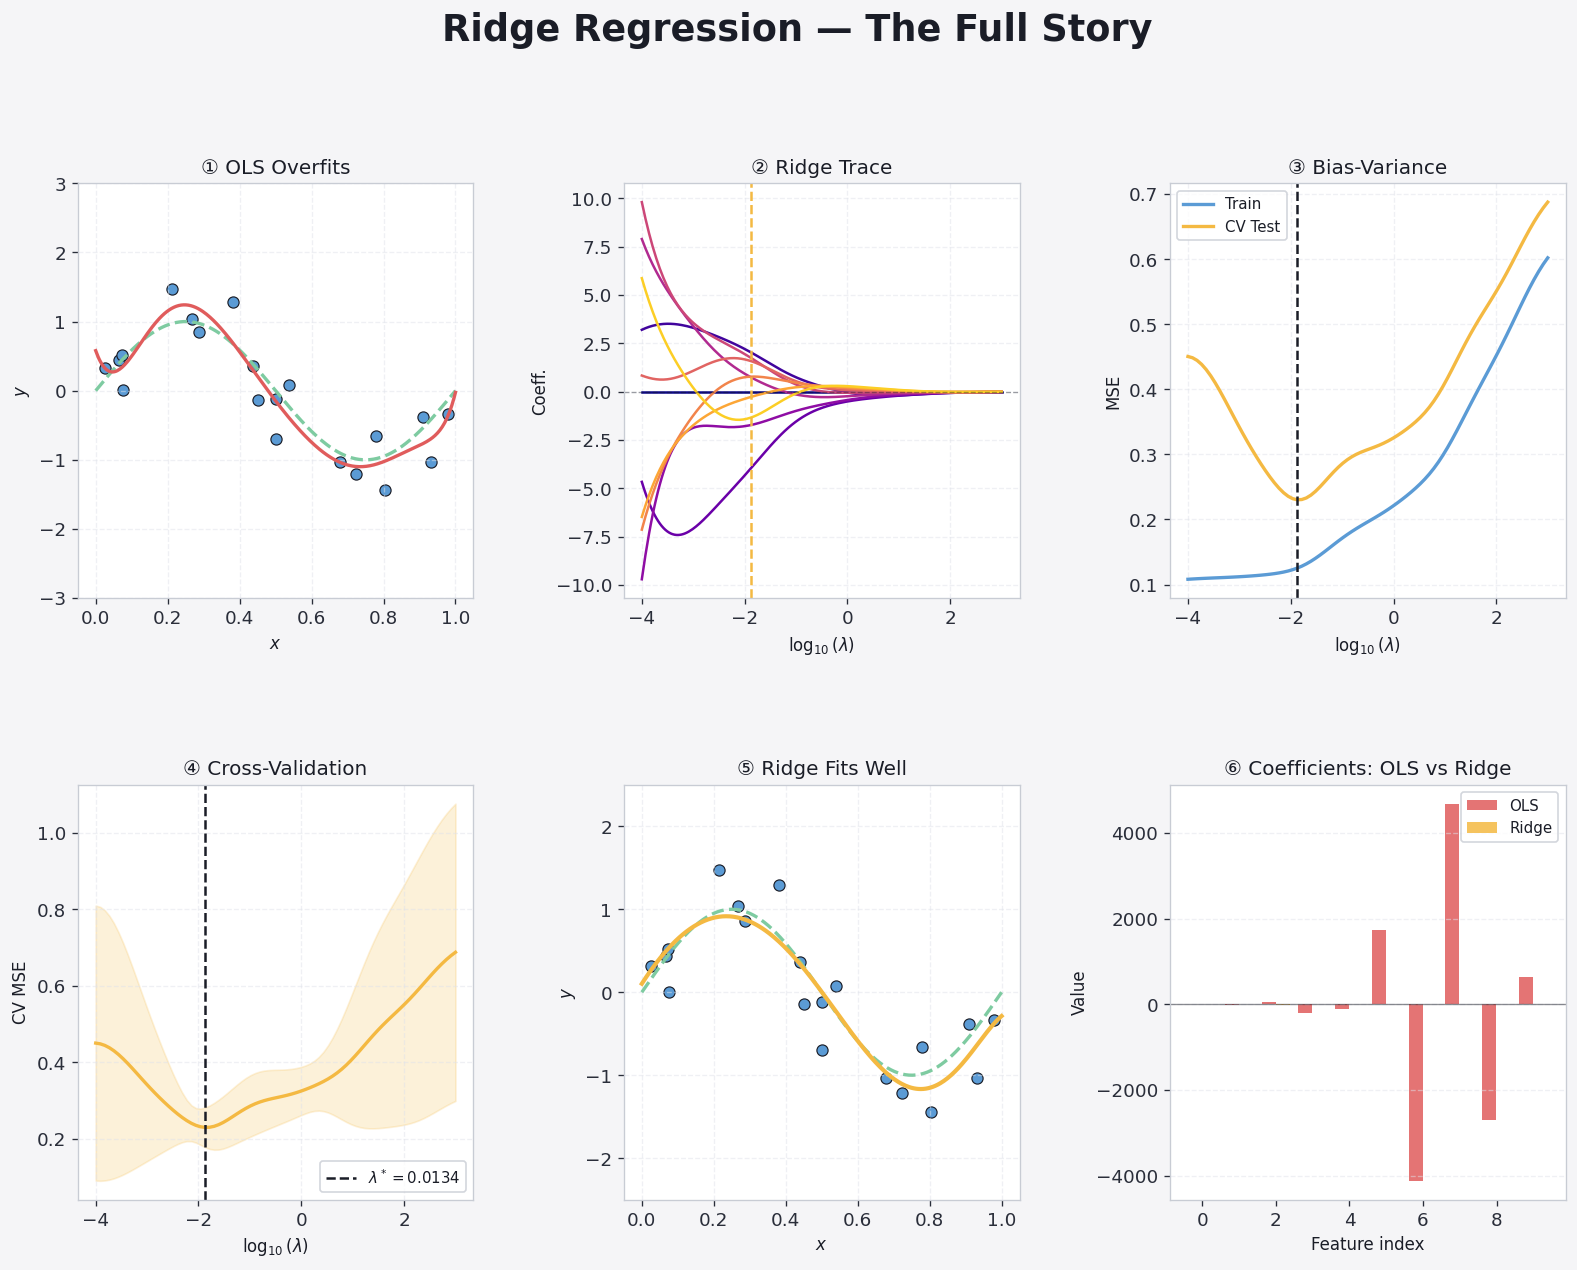

In [13]:
fig = plt.figure(figsize=(16, 11), facecolor='#f5f5f7')
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── (0,0) OLS overfit ────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.plot(x_pl, y_true, color=C_TRUE, lw=2, ls='--')
ax.plot(x_pl, pipe_ols2.predict(x_pl.reshape(-1,1)), color=C_OLS, lw=2)
ax.scatter(x_tr, y_tr, s=45, c=C_DATA, edgecolors='#1a1d27', lw=0.7)
ax.set_ylim(-3, 3); ax.grid(True)
ax.set_title('① OLS Overfits', fontsize=12)
ax.set_xlabel('$x$', fontsize=10); ax.set_ylabel('$y$', fontsize=10)

# ── (0,1) Ridge trace ────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
cmap = plt.cm.plasma
for j in range(coef_paths.shape[1]):
    ax.plot(np.log10(alphas), coef_paths[:, j], color=cmap(j/coef_paths.shape[1]), lw=1.5)
ax.axhline(0, color='#1a1d27', ls='--', lw=0.8, alpha=0.4)
ax.axvline(np.log10(best_alpha), color=C_RIDGE, ls='--', lw=1.5)
ax.set_title('② Ridge Trace', fontsize=12)
ax.set_xlabel('$\\log_{10}(\\lambda)$', fontsize=10); ax.set_ylabel('Coeff.', fontsize=10)
ax.grid(True)

# ── (0,2) Bias-variance ──────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
ax.plot(np.log10(alphas_cv), train_mse_arr, color=C_DATA, lw=2, label='Train')
ax.plot(np.log10(alphas_cv), cv_mean, color=C_RIDGE, lw=2, label='CV Test')
ax.axvline(np.log10(best_alpha), color='#1a1d27', ls='--', lw=1.5)
ax.set_title('③ Bias-Variance', fontsize=12)
ax.set_xlabel('$\\log_{10}(\\lambda)$', fontsize=10); ax.set_ylabel('MSE', fontsize=10)
ax.grid(True); ax.legend(fontsize=9)

# ── (1,0) CV curve ───────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.plot(np.log10(alphas_cv), cv_mean, color=C_RIDGE, lw=2)
ax.fill_between(np.log10(alphas_cv), cv_mean-cv_std, cv_mean+cv_std, color=C_RIDGE, alpha=0.2)
ax.axvline(np.log10(best_alpha), color='#1a1d27', ls='--', lw=1.5,
           label=f'$\\lambda^*={best_alpha:.4f}$')
ax.set_title('④ Cross-Validation', fontsize=12)
ax.set_xlabel('$\\log_{10}(\\lambda)$', fontsize=10); ax.set_ylabel('CV MSE', fontsize=10)
ax.grid(True); ax.legend(fontsize=9)

# ── (1,1) Ridge fit ───────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
ax.plot(x_pl, y_true, color=C_TRUE, lw=2, ls='--')
ax.plot(x_pl, pipe_ridge.predict(x_pl.reshape(-1,1)), color=C_RIDGE, lw=2.5)
ax.scatter(x_tr, y_tr, s=45, c=C_DATA, edgecolors='#1a1d27', lw=0.7)
ax.set_ylim(-2.5, 2.5); ax.grid(True)
ax.set_title('⑤ Ridge Fits Well', fontsize=12)
ax.set_xlabel('$x$', fontsize=10); ax.set_ylabel('$y$', fontsize=10)

# ── (1,2) Coefficient comparison ─────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
coef_ols   = pipe_ols2.named_steps['model'].coef_
coef_ridge = pipe_ridge.named_steps['model'].coef_
idx = np.arange(len(coef_ols))
ax.bar(idx - 0.2, coef_ols,   width=0.38, color=C_OLS,   label='OLS', alpha=0.85)
ax.bar(idx + 0.2, coef_ridge, width=0.38, color=C_RIDGE, label='Ridge', alpha=0.85)
ax.axhline(0, color='#1a1d27', lw=0.8, alpha=0.5)
ax.set_title('⑥ Coefficients: OLS vs Ridge', fontsize=12)
ax.set_xlabel('Feature index', fontsize=10); ax.set_ylabel('Value', fontsize=10)
ax.legend(fontsize=9); ax.grid(True, axis='y')

fig.suptitle('Ridge Regression — The Full Story', fontsize=22, fontweight='bold',
             color='#1a1d27', y=1.01)
plt.show()

---
## ⚖️ When to use Ridge — and when not to

| Situation | Ridge | Lasso | Elastic Net | Plain OLS |
|---|---|---|---|---|
| Many correlated features | ✅ shrinks together | ❌ keeps one at random | ✅ groups them | ❌ unstable |
| Want feature selection | ❌ keeps all | ✅ zeroes some | ✅ zeroes some | ❌ |
| $p \gg n$ | ✅ stable | ✅ stable | ✅ stable | ❌ singular |
| Need closed form | ✅ $(X^TX+\lambda I)^{-1}X^Ty$ | ❌ iterative | ❌ iterative | ✅ |

> Default to **Ridge** when you want a stable, low-variance fit and don't need sparsity.


---
## 🎯 Try this

1. **Vary correlation.** Regenerate the design with two near-duplicate features. Watch how OLS coefficients flip between huge $\pm$ values while Ridge keeps both small and similar.
2. **Effective degrees of freedom.** Compute $\mathrm{tr}(X(X^TX+\lambda I)^{-1}X^T)$ for a sweep of $\lambda$ and verify it shrinks from $p$ at $\lambda=0$ toward $0$.
3. **Bayesian view.** Ridge $=$ MAP under a Gaussian prior $\theta \sim \mathcal{N}(0, \sigma^2/\lambda \cdot I)$. Sample from this prior for several $\lambda$ and overlay the curves with the fitted Ridge solution.


---
## Summary

| Concept | Formula | Key Insight |
|---|---|---|
| OLS cost | $J(\theta) = \frac{1}{2m}\sum_i (h_\theta(x^{(i)}) - y^{(i)})^2$ | Minimises training error; can overfit |
| Ridge cost | $J_\text{Ridge}(\theta) = J(\theta) + \lambda \sum_j \theta_j^2$ | Adds L2 penalty; shrinks all $\theta_j$ toward 0 |
| Closed form | $\theta = (X^TX + \lambda I)^{-1} X^T y$ | Always invertible even when $X^TX$ is singular |
| Ridge trace | Coefficients vs $\lambda$ | All shrink smoothly — no exact zeros |
| $\lambda=0$ | Plain OLS | No regularisation |
| $\lambda \to \infty$ | All $\theta_j \to 0$ | Maximum shrinkage (underfits) |
| Optimal $\lambda$ | Chosen by cross-validation | Minimises held-out error |

**Key insight:** Ridge regression prevents overfitting by penalising large coefficients. The amount of shrinkage is controlled by $\lambda$ and selected via cross-validation. Unlike Lasso, Ridge never zeroes out coefficients — it keeps all features but makes them small.